In [1]:
from sklearn.datasets import make_classification
import numpy as np
X, y = make_classification(n_samples=100, n_features=2, n_informative=1,n_redundant=0,
                           n_classes=2, n_clusters_per_class=1, random_state=41,hypercube=False,class_sep=20)

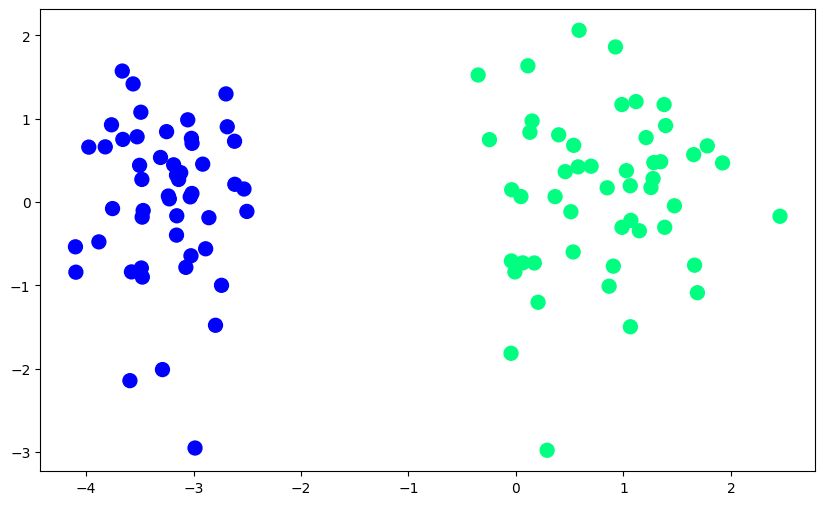

In [2]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10,6))
plt.scatter(X[:,0],X[:,1],c=y,cmap='winter',s=100)

In [3]:
from sklearn.linear_model import LogisticRegression

In [7]:
lor = LogisticRegression(penalty=None,solver='sag')
lor.fit(X,y)

C:\Users\Harshgupta\anaconda3\envs\harsenv\lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


,penalty,None
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'sag'
,max_iter,100
,multi_class,'deprecated'


In [8]:
print(lor.coef_)
print(lor.intercept_)

[[4.77868981 0.20397708]]
[5.74919385]


In [9]:
m1 = -(lor.coef_[0][0]/lor.coef_[0][1])
b1 = -(lor.intercept_/lor.coef_[0][1])

In [10]:
x_input = np.linspace(-3,3,100)
y_input = m1*x_input + b1

In [16]:
def sigmoid (X):
    return 1/(1+ np.exp(-X))

In [32]:
def mera_lor(X,y):
    lr = 0.5
    X = np.insert(X,0,1,axis=1)
    weights = np.ones(X.shape[1]) ## randomly start like here [1,1,1]
    
    for i in range(4500):
        y_hat = sigmoid(np.dot(X,weights))
        weights = weights + lr * (np.dot((y-y_hat),X)/X.shape[0])

    return weights[1:],weights[0]

In [33]:
coef_,intercept_ = mera_lor(X,y)

In [34]:
coef_

array([4.76591118, 0.20542846])

In [35]:
intercept_

np.float64(5.728240756595195)

In [36]:
m = -(coef_[0]/coef_[1])
b = -(intercept_/coef_[1])
x_input1 = np.linspace(-3,3,100)
y_input1 = m*x_input1 + b

(-3.0, 2.0)

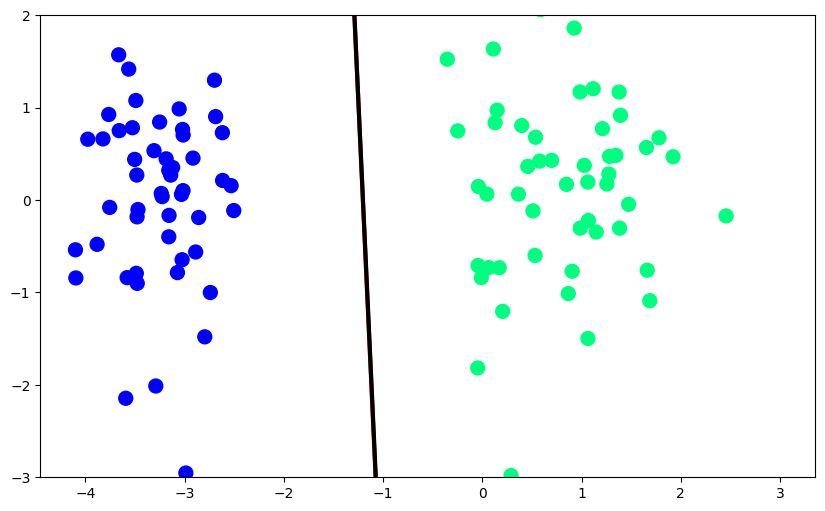

In [37]:
plt.figure(figsize=(10,6))
plt.plot(x_input,y_input,color='red',linewidth=3)
plt.plot(x_input1,y_input1,color='black',linewidth=3)
plt.scatter(X[:,0],X[:,1],c=y,cmap='winter',s=100)
plt.ylim(-3,2)